In [4]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# 1. CARREGAMENTO DOS DADOS

In [5]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset.csv")

print("Shape:", df.shape)
print("\nColunas:\n", df.columns.tolist())
print("\nDistribuicao do Target:")
print(df["Sleep Disorder"].value_counts())
print("\nValores nulos:\n", df.isnull().sum())

Shape: (374, 13)

Colunas:
 ['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level', 'Stress Level', 'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps', 'Sleep Disorder']

Distribuicao do Target:
Sleep Disorder
Sleep Apnea    78
Insomnia       77
Name: count, dtype: int64

Valores nulos:
 Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64


# 2. PRE-PROCESSAMENTO

In [6]:
# 2.1 Tratar valores nulos na coluna target (sem disturbio = "None")
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

# 2.2 Extrair pressao sistolica e diastolica da coluna "Blood Pressure"
df[["BP_Systolic", "BP_Diastolic"]] = (
    df["Blood Pressure"].str.split("/", expand=True).astype(float)
)
df.drop(columns=["Blood Pressure"], inplace=True)

# 2.3 Remover colunas irrelevantes para o modelo de habitos
df.drop(columns=["Person ID"], inplace=True, errors="ignore")

# 2.4 Encode de variaveis categoricas
label_encoders = {}
categorical_cols = ["Gender", "Occupation", "BMI Category"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# 2.5 Encode do target
le_target = LabelEncoder()
df["Sleep Disorder"] = le_target.fit_transform(df["Sleep Disorder"])
print("\nClasses do target:", le_target.classes_)


Classes do target: ['Insomnia' 'None' 'Sleep Apnea']


# 3. SEPARACAO FEATURES / TARGET

In [7]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

print("\nFeatures utilizadas:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:02d}. {col}")


Features utilizadas:
  01. Gender
  02. Age
  03. Occupation
  04. Sleep Duration
  05. Quality of Sleep
  06. Physical Activity Level
  07. Stress Level
  08. BMI Category
  09. Heart Rate
  10. Daily Steps
  11. BP_Systolic
  12. BP_Diastolic


# 4. DIVISAO TREINO / TESTE

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTreino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")


Treino: 299 amostras
Teste:  75 amostras


# 5. NORMALIZACAO

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 6. MODELO MLP

In [10]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,           
    batch_size=32,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=42,
    verbose=False
)

mlp.fit(X_train_scaled, y_train)
print(f"\nEpocas treinadas: {mlp.n_iter_}")


Epocas treinadas: 42


# 7. AVALIACAO

In [11]:
y_pred = mlp.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)

print(f"\n=== RESULTADOS ===")
print(f"Acuracia no Teste: {acc:.4f} ({acc*100:.2f}%)")

print("\nRelatorio de Classificacao:")
print(classification_report(
    y_test, y_pred,
    target_names=le_target.classes_
))

cv_scores = cross_val_score(mlp, X_train_scaled, y_train, cv=5, scoring="accuracy")
print(f"Cross-Validation (5-fold): {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")


=== RESULTADOS ===
Acuracia no Teste: 0.9200 (92.00%)

Relatorio de Classificacao:
              precision    recall  f1-score   support

    Insomnia       0.92      0.80      0.86        15
        None       0.96      0.98      0.97        44
 Sleep Apnea       0.82      0.88      0.85        16

    accuracy                           0.92        75
   macro avg       0.90      0.88      0.89        75
weighted avg       0.92      0.92      0.92        75

Cross-Validation (5-fold): 0.8662 +/- 0.0559


# 8. VISUALIZACOES

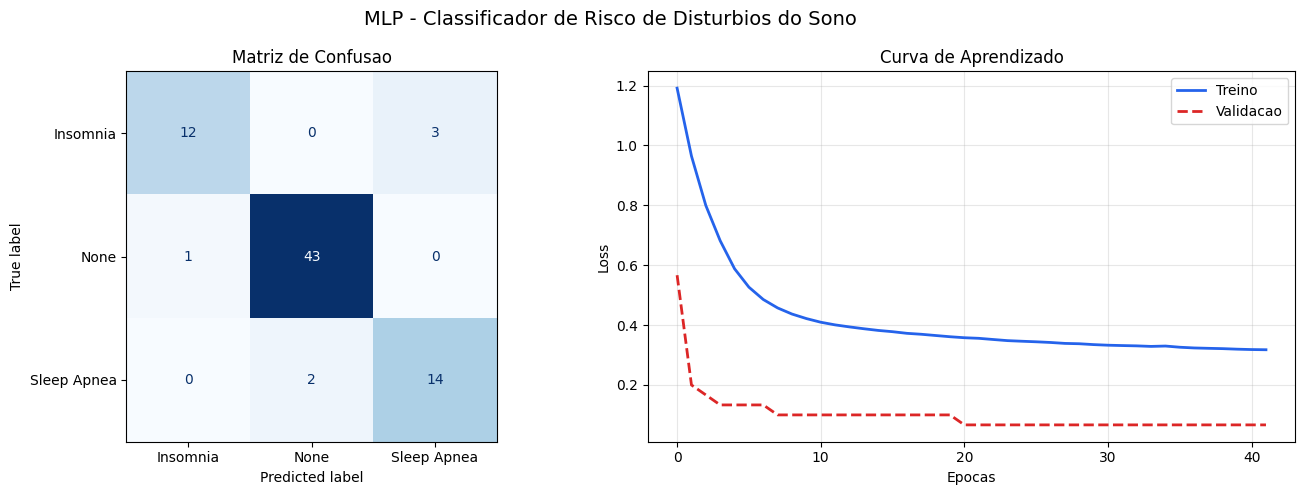

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("MLP - Classificador de Risco de Disturbios do Sono", fontsize=14)

# 8.1 Matriz de Confusao
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Matriz de Confusao")

axes[1].plot(mlp.loss_curve_, label="Treino", color="#2563eb", linewidth=2)
if mlp.validation_scores_ is not None:
    val_loss = [1 - s for s in mlp.validation_scores_]
    axes[1].plot(val_loss, label="Validacao", color="#dc2626", linewidth=2, linestyle="--")
axes[1].set_xlabel("Epocas")
axes[1].set_ylabel("Loss")
axes[1].set_title("Curva de Aprendizado")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mlp_resultados.png", dpi=150, bbox_inches="tight")
plt.show()

# 9. IMPORTANCIA DAS FEATURES (via permutacao)


Importancia das Features (Permutacao):
                Feature  Importancia
                    Age     0.039111
                 Gender     0.038222
           BMI Category     0.032889
            BP_Systolic     0.032000
           BP_Diastolic     0.025778
            Daily Steps     0.009333
             Heart Rate     0.009333
             Occupation     0.006667
Physical Activity Level     0.002222
         Sleep Duration    -0.001778
           Stress Level    -0.010667
       Quality of Sleep    -0.014222


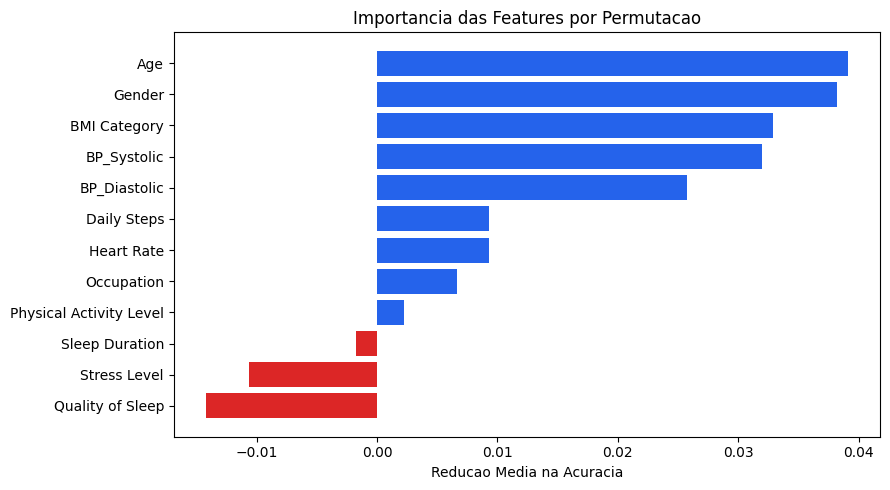

In [13]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    mlp, X_test_scaled, y_test,
    n_repeats=30,
    random_state=42,
    scoring="accuracy"
)

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importancia": perm.importances_mean
}).sort_values("Importancia", ascending=False)

print("\nImportancia das Features (Permutacao):")
print(feat_imp.to_string(index=False))

plt.figure(figsize=(9, 5))
colors = ["#2563eb" if v > 0 else "#dc2626" for v in feat_imp["Importancia"]]
plt.barh(feat_imp["Feature"], feat_imp["Importancia"], color=colors)
plt.xlabel("Reducao Media na Acuracia")
plt.title("Importancia das Features por Permutacao")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("mlp_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

# 10. DEMO: PREDICAO PARA UM NOVO USUARIO

In [14]:
print("\n=== DEMO: Predicao para novo usuario ===")

novo_usuario = pd.DataFrame([{
    "Gender": 1,                  # 1 = Male
    "Age": 35,
    "Occupation": 3,              # ex: Engineer
    "Sleep Duration": 6.0,        # horas
    "Quality of Sleep": 5,        # escala 1-10
    "Physical Activity Level": 30,# minutos/dia
    "Stress Level": 8,            # escala 1-10
    "BMI Category": 2,            # Overweight
    "Heart Rate": 78,
    "Daily Steps": 4000,
    "BP_Systolic": 130,
    "BP_Diastolic": 85
}])


novo_usuario = novo_usuario[X.columns]
novo_scaled  = scaler.transform(novo_usuario)
pred_class   = mlp.predict(novo_scaled)
pred_proba   = mlp.predict_proba(novo_scaled)

print(f"Classe Predita: {le_target.inverse_transform(pred_class)[0]}")
print("Probabilidades:")
for cls, prob in zip(le_target.classes_, pred_proba[0]):
    print(f"  {cls:12s}: {prob*100:.1f}%")


=== DEMO: Predicao para novo usuario ===
Classe Predita: Insomnia
Probabilidades:
  Insomnia    : 66.4%
  None        : 25.3%
  Sleep Apnea : 8.3%
